<a href="https://colab.research.google.com/github/Bryan-Rico/Lenguajes_de_Programaci-n-/blob/main/Modulo_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Celda 1: instalar e importar
!pip install yfinance --quiet
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

print("¡Listo para analizar cripto!")

¡Listo para analizar cripto!


In [ ]:
eth = yf.download('ETH-USD',
  start='2024-01-01',
  end='2024-12-31',
  interval='1d')

/tmp/ipykernel_3134/1681070759.py:1: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [ ]:
eth.head()

Price,Close,High,Low,Open,Volume
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD
Date,,,,,
2024-01-01,2352.327881,2352.327881,2267.018066,2282.870361,6906765990
2024-01-02,2355.836426,2431.212402,2348.892334,2352.593506,12910543630
2024-01-03,2210.761963,2385.117676,2113.925293,2355.981445,19332933581
2024-01-04,2269.038086,2294.608154,2204.865723,2210.529053,11044564896
2024-01-05,2268.647217,2276.764648,2209.537109,2269.409424,10860953290


In [ ]:
eth.describe()

Price,Close,High,Low,Open,Volume
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD
count,365.000000,365.000000,365.000000,365.000000,3.650000e+02
mean,3044.140663,3114.444872,2964.102849,3041.193169,1.903421e+10
std,510.283842,523.554650,494.224703,511.444624,1.123208e+10
min,2210.761963,2240.380859,2113.925293,2210.529053,4.578472e+09
25%,2565.348145,2629.383545,2495.214355,2560.879639,1.180044e+10
50%,3084.920166,3156.366211,3016.144043,3075.722900,1.599389e+10
75%,3480.271973,3539.904297,3372.214111,3479.785645,2.210487e+10
max,4066.445068,4106.955566,3974.176270,4066.690430,6.766813e+10


In [ ]:
eth.columns

MultiIndex([( 'Close', 'ETH-USD'),
            (  'High', 'ETH-USD'),
            (   'Low', 'ETH-USD'),
            (  'Open', 'ETH-USD'),
            ('Volume', 'ETH-USD')],
           names=['Price', 'Ticker'])

In [ ]:
eth.shape

(365, 5)

In [ ]:
# eth['Close'] tiene los precios de cierre
eth['retorno'] = eth['Close'].pct_change()


In [ ]:
print(eth['retorno'].head())

Date
2024-01-01         NaN
2024-01-02    0.001492
2024-01-03   -0.061581
2024-01-04    0.026360
2024-01-05   -0.000172
Name: retorno, dtype: float64


In [ ]:
vol_anual = eth['retorno'].std() * np.sqrt(252)

In [ ]:
print(vol_anual)

0.5416991824444685


In [ ]:
# Línea de precios
eth.columns = eth.columns.get_level_values(0)
fig = px.line(eth, x=eth.index, y='Close', title='Precio de cierre de ETH')
fig.show()


In [ ]:
# Histograma de retornos
fig2 = px.histogram(eth, x='retorno', nbins=100, title='Histograma de retornos')
fig2.show()

<Axes: >

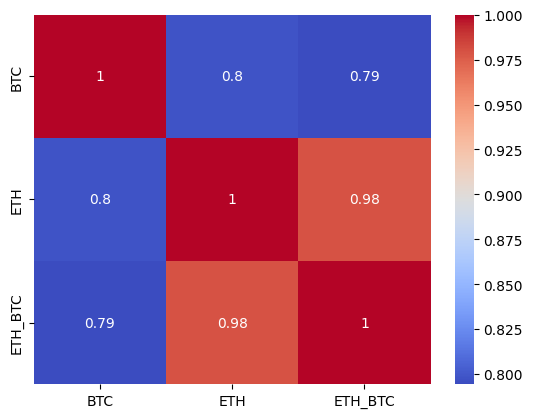

In [ ]:
# Calcular rotación
returns = pd.DataFrame({
  'BTC': btc['Close'].squeeze().pct_change(),
  'ETH': eth['Close'].squeeze().pct_change(),
  'ETH_BTC': eth['Close'].squeeze().pct_change() / btc['Close'].squeeze()
})

# Calcular matriz de correlación
corr = returns.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

In [ ]:
!pip install

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 98.1 MB/s eta 0:00:00


In [ ]:
import streamlit as st

In [ ]:
st.set_page_config(page_title='Panel de Control ETH', page_icon=':bar_chart:', layout='wide')
st.title('Analisis Cripto ETH - Concurso 2026')

# Widget interactivo
eth = st.selectbox('ETH-USD', ('ETH-USD'))
periodo = st.slider('365')

#Descarga de datos
df = yf.download('ETH-USD',
  start='2024-01-01',
  end='2024-12-31',
  interval='1d')
df['retorno'] = df['Close'].pct_change()

#Métricas
col1, col2, col3 = st.columns(3)
col1.metric("Precio actual", f"${df['Close'].iloc[-1]:,.2f}")
col2.metric("Retorno diario", f"{(df['Close'].iloc[-1]/df['Close'].iloc[0] - 1)*100:.1f}%")
col3.metric("Volatilidad Anual", f"{df['retorno'].std()*(252**0.5)*100:.1f}%")

2026-05-01 01:15:33.185 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-01 01:15:33.187 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-01 01:15:33.188 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-01 01:15:33.190 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-01 01:15:33.191 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-01 01:15:33.193 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-01 01:15:33.195 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-01 01:15:33.196 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

TypeError: unsupported format string passed to Series.__format__